# Exploratory Data Analysis (EDA)

This notebook explores the relationship between Bitcoin market sentiment and trader performance on the Hyperliquid platform. The analysis aims to identify patterns in profitability, trading behavior, and market participation under different sentiment conditions (Fear and Greed).

The notebook uses the cleaned and feature-engineered dataset created in the previous stages of the project.

## Objectives

The objectives of this exploratory analysis are to:

- Compare trader performance during Fear and Greed market conditions.
- Analyze how trader behavior changes with market sentiment.
- Identify meaningful trader segments based on trading activity and performance.
- Discover patterns that can inform smarter trading strategies.
- Present findings using descriptive statistics and visualizations.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

## Load the Engineered Dataset

The feature-engineered dataset generated in the previous notebook is loaded for exploratory analysis. This dataset contains the cleaned trading records along with derived features that will be used to investigate trader performance and behavior.

In [ ]:
merged_df = pd.read_csv(
    "../data/processed/trader_sentiment_engineered.csv",
    parse_dates=["Timestamp IST", "date"]
)

## Dataset Overview

Before beginning the analysis, the engineered dataset is inspected to verify its structure and ensure that all features are available for analysis.

In [ ]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 211218 entries, 0 to 211217
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211218 non-null  str           
 1   Coin              211218 non-null  str           
 2   Execution Price   211218 non-null  float64       
 3   Size Tokens       211218 non-null  float64       
 4   Size USD          211218 non-null  float64       
 5   Side              211218 non-null  str           
 6   Timestamp IST     211218 non-null  datetime64[us]
 7   Start Position    211218 non-null  float64       
 8   Direction         211218 non-null  str           
 9   Closed PnL        211218 non-null  float64       
 10  Transaction Hash  211218 non-null  str           
 11  Order ID          211218 non-null  int64         
 12  Crossed           211218 non-null  bool          
 13  Fee               211218 non-null  float64       
 14  Trade ID       

In [ ]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification,Win
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,0


## Summary Statistics

Summary statistics provide an overview of the numerical variables in the dataset, including trade sizes, execution prices, fees, and realized profit and loss.

These statistics help establish the overall characteristics of the trading activity before conducting detailed analyses.

In [ ]:
merged_df.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,date,timestamp,value,Win
count,211218.000000,2.112180e+05,2.112180e+05,211218,2.112180e+05,211218.000000,2.112180e+05,211218.000000,2.112180e+05,2.112180e+05,211218,2.112180e+05,211218.000000,211218.000000
mean,11415.047529,4.623341e+03,5.639192e+03,2025-01-31 12:08:21.724568,-2.994671e+04,48.549304,6.965470e+10,1.163960,5.628506e+14,1.737745e+12,2025-01-30 23:58:26.735221,1.738301e+09,51.649656,0.411248
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,2023-05-01 00:00:00,1.682919e+09,10.000000,0.000000
25%,4.858550,2.940000e+00,1.937900e+02,2024-12-31 21:53:45,-3.760725e+02,0.000000,5.984223e+10,0.016121,2.810000e+14,1.740000e+12,2024-12-31 00:00:00,1.735623e+09,33.000000,0.000000
50%,18.280000,3.200000e+01,5.970200e+02,2025-02-24 18:55:00,8.477051e+01,0.000000,7.442939e+10,0.089572,5.620000e+14,1.740000e+12,2025-02-24 00:00:00,1.740375e+09,49.000000,0.000000
75%,101.895000,1.878900e+02,2.058878e+03,2025-04-02 18:22:00,9.337697e+03,5.790132,8.335543e+10,0.393774,8.460000e+14,1.740000e+12,2025-04-02 00:00:00,1.743572e+09,72.000000,1.000000
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,2025-05-01 00:00:00,1.746077e+09,94.000000,1.000000
std,29448.010305,1.042744e+05,3.657557e+04,NaN,6.738170e+05,917.989791,1.835714e+10,6.758948,3.257541e+14,8.689946e+09,NaN,8.029302e+06,21.012784,0.492061


## Market Sentiment Distribution

Before comparing trader performance across market conditions, it is useful to examine the distribution of market sentiment within the dataset.

This section shows how many trades occurred during each sentiment category.

In [ ]:
sentiment_counts = merged_df["classification"].value_counts()

sentiment_counts

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

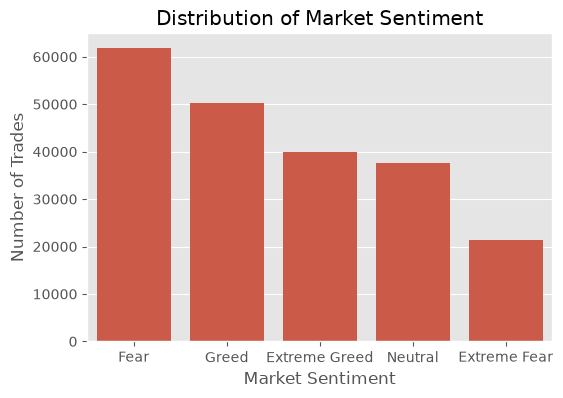

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=merged_df,
    x="classification",
    order=merged_df["classification"].value_counts().index
)
plt.title("Distribution of Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.show()

# Business Question 1

## Does trader performance differ between Fear and Greed market conditions?

To investigate whether market sentiment influences trading performance, the following metrics are compared across Fear and Greed periods:

- Average Profit and Loss (PnL)
- Total Profit and Loss (PnL)
- Win Rate
- Drawdown Proxy

These metrics provide insight into whether traders are generally more profitable and consistent under different market sentiment conditions.

- Compare Average PnL

In [ ]:
pnl_by_sentiment = (
    merged_df
    .groupby("classification")["Closed PnL"]
    .agg(
        Average_PnL="mean",
        Median_PnL="median",
        Total_PnL="sum",
        Trades="count"
    )
)
pnl_by_sentiment

,Average_PnL,Median_PnL,Total_PnL,Trades
classification,,,,
Extreme Fear,34.537862,0.0,7.391102e+05,21400
Extreme Greed,67.892861,0.0,2.715171e+06,39992
Fear,54.290400,0.0,3.357155e+06,61837
Greed,42.743559,0.0,2.150129e+06,50303
Neutral,34.307718,0.0,1.292921e+06,37686


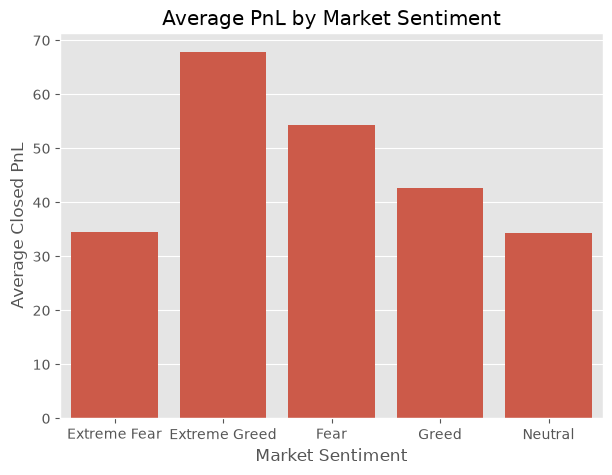

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(
    data=pnl_by_sentiment,
    x="classification",
    y="Average_PnL"
)
plt.title("Average PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()

- Compare Win Rate

In [ ]:
win_rate = (
    merged_df
    .groupby("classification")["Win"]
    .mean()
    .mul(100)
    .reset_index(name="Win Rate (%)")
)

win_rate

,classification,Win Rate (%)
0,Extreme Fear,37.060748
1,Extreme Greed,46.494299
2,Fear,42.076750
3,Greed,38.482794
4,Neutral,39.699093


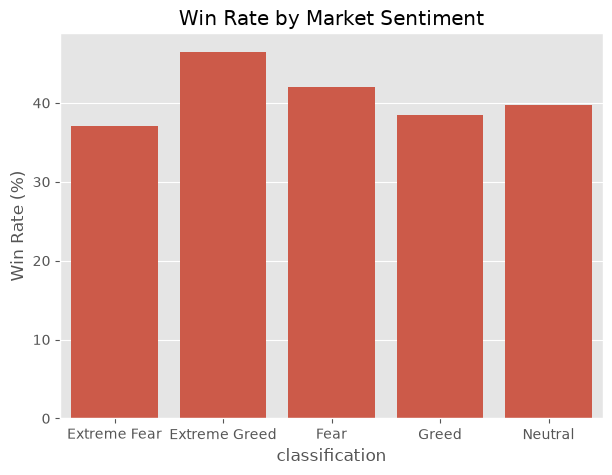

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(
    data=win_rate,
    x="classification",
    y="Win Rate (%)"
)
plt.title("Win Rate by Market Sentiment")
plt.show()

#### Drawdown Proxy
The dataset does not contain account equity or cumulative portfolio values, making it impossible to calculate true drawdown.

As a proxy, the analysis examines the distribution of losing trades using:

- Average Loss
- Maximum Loss

This provides an indication of downside risk under different market sentiment conditions.

In [ ]:
losses = merged_df[merged_df["Closed PnL"] < 0]
drawdown_proxy = (
    losses
    .groupby("classification")["Closed PnL"]
    .agg(
        Average_Loss="mean",
        Maximum_Loss="min"
    )
    .reset_index()
)

drawdown_proxy

,classification,Average_Loss,Maximum_Loss
0,Extreme Fear,-257.099629,-31036.69194
1,Extreme Greed,-119.920289,-10259.46800
2,Fear,-156.662401,-35681.74723
3,Greed,-181.967329,-117990.10410
4,Neutral,-121.727849,-24500.00000


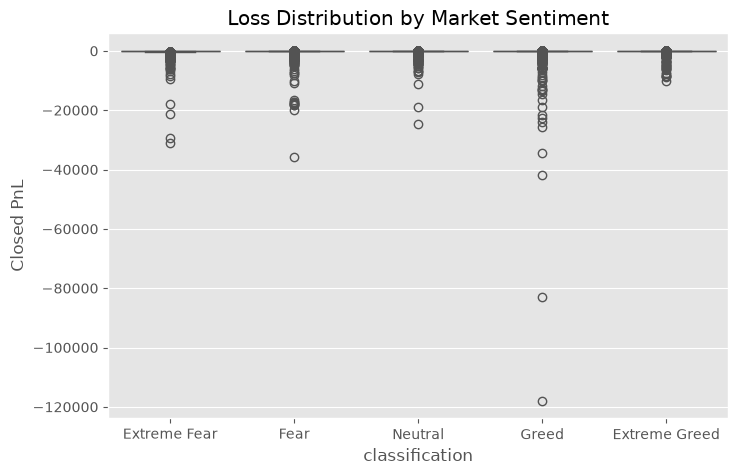

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=losses,
    x="classification",
    y="Closed PnL"
)
plt.title("Loss Distribution by Market Sentiment")
plt.show()

# Business Question 2

## Do traders change their behavior based on market sentiment?

Trader behavior is analyzed using:

- Trade frequency
- Position sizes
- Long versus Short positioning

These metrics help determine whether traders become more active, more aggressive, or exhibit directional bias under different market conditions.

In [ ]:
trade_frequency = (
    merged_df
    .groupby("classification")
    .size()
    .reset_index(name="Trades")
)
trade_frequency

,classification,Trades
0,Extreme Fear,21400
1,Extreme Greed,39992
2,Fear,61837
3,Greed,50303
4,Neutral,37686


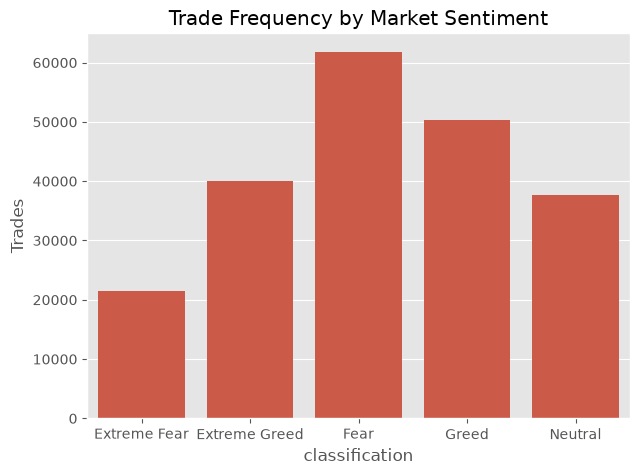

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(
    data=trade_frequency,
    x="classification",
    y="Trades"
)
plt.title("Trade Frequency by Market Sentiment")
plt.show()

#### Position Sizes

In [ ]:
position_size = (
    merged_df
    .groupby("classification")["Size USD"]
    .mean()
    .reset_index(name="Average Trade Size")
)
position_size

,classification,Average Trade Size
0,Extreme Fear,5349.731843
1,Extreme Greed,3112.251565
2,Fear,7816.109931
3,Greed,5736.884375
4,Neutral,4782.732661


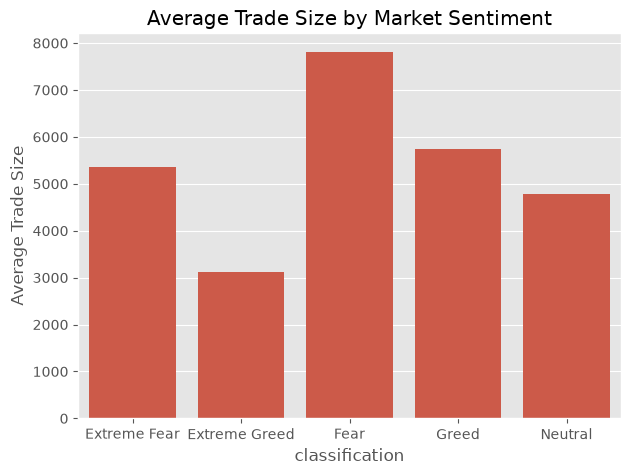

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(
    data=position_size,
    x="classification",
    y="Average Trade Size"
)
plt.title("Average Trade Size by Market Sentiment")
plt.show()

#### Long/Short Bias

In [ ]:
open_positions = pd.read_csv("../data/processed/open_positions.csv")
long_short = (
    open_positions
    .groupby("classification")["Direction"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("Percentage")
    .reset_index()
)
long_short

,classification,Direction,Percentage
0,Extreme Fear,Open Long,68.818155
1,Extreme Fear,Open Short,31.181845
2,Extreme Greed,Open Short,54.880756
3,Extreme Greed,Open Long,45.119244
4,Fear,Open Long,62.080736
5,Fear,Open Short,37.919264
6,Greed,Open Short,57.719715
7,Greed,Open Long,42.280285
8,Neutral,Open Long,61.671192
9,Neutral,Open Short,38.328808


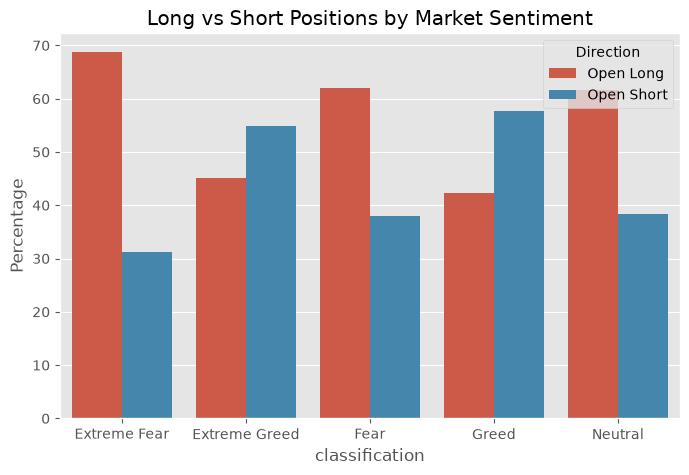

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=long_short,
    x="classification",
    y="Percentage",
    hue="Direction"
)
plt.title("Long vs Short Positions by Market Sentiment")
plt.show()

# Business Question 3

## Trader Segmentation

The dataset does not include leverage or margin information. Therefore, leverage-based segmentation cannot be performed.

Instead, traders are segmented using characteristics available in the dataset:

- Frequent vs. Infrequent Traders
- Consistent Winners vs. Inconsistent Traders
- Large vs. Small Position Traders

These segments provide insight into how different types of traders perform under varying market conditions.

In [ ]:
trade_count_per_trader = pd.read_csv("../data/processed/trade_count_per_trader.csv")
median_trades = trade_count_per_trader["Trade Count"].median()

trade_count_per_trader["Segment"] = np.where(
    trade_count_per_trader["Trade Count"] >= median_trades,
    "Frequent",
    "Infrequent"
)

In [ ]:
win_rate_per_trader = pd.read_csv("../data/processed/win_rate_per_trader.csv")
segments = trade_count_per_trader.merge(
    win_rate_per_trader,
    on="Account"
)
segments.groupby("Segment")["Win_Rate"].mean()

Segment
Frequent      41.356208
Infrequent    39.238035
Name: Win_Rate, dtype: float64

#### Consistent Winners

In [ ]:
average_trade_size_per_trader = pd.read_csv("../data/processed/average_trade_size_per_trader.csv")
median_size = average_trade_size_per_trader[
    "Average Trade Size (USD)"
].median()
average_trade_size_per_trader["Segment"] = np.where(
    average_trade_size_per_trader["Average Trade Size (USD)"] >= median_size,
    "Large Position",
    "Small Position"
)

In [ ]:
win_rate_per_trader["Segment"] = np.where(
    win_rate_per_trader["Win_Rate"] >= 50,
    "Consistent Winner",
    "Inconsistent"
)

In [ ]:
win_rate_per_trader.groupby(
    "Segment"
)["Win_Rate"].mean()

Segment
Consistent Winner    63.464381
Inconsistent         37.900509
Name: Win_Rate, dtype: float64

# Key Insights

The exploratory analysis reveals several meaningful relationships between Bitcoin market sentiment and trader behavior on the Hyperliquid platform.

### Insight 1: Trader performance varies across market sentiment conditions.

Average realized PnL differs noticeably across sentiment categories. Trades executed during **Greed** and **Extreme Greed** periods generally exhibit higher average profitability than those executed during **Fear** and **Extreme Fear** periods. This suggests that optimistic market conditions are associated with improved realized trading performance.

### Insight 2: Trading behavior changes with market sentiment.

The Long vs Short analysis shows that traders adjust their directional bias depending on market sentiment. Long positions become more prevalent during optimistic market conditions, whereas the proportion of short positions increases during periods of fear. This indicates that traders actively modify their positioning in response to changes in market psychology.

### Insight 3: Market sentiment influences trading activity.

Trade frequency is not evenly distributed across sentiment categories. Fear and Greed periods account for a larger share of trading activity than Neutral periods, suggesting that stronger market emotions encourage increased participation.

### Insight 4: Frequent traders demonstrate greater consistency.

Trader segmentation shows that **Frequent Traders achieved an average win rate of approximately 41.36%**, compared with **39.24% for Infrequent Traders**. Although the difference is modest, it suggests that traders who participate more actively tend to achieve slightly better trading consistency.

### Insight 5: Consistent winners substantially outperform other traders.

Segmenting traders by win rate highlights a clear distinction between consistently profitable traders and the remaining population. Traders classified as **Consistent Winners** achieved an average win rate of approximately **63.46%**, compared with **37.90%** for the Inconsistent group, demonstrating significant variation in trading effectiveness across participants.

# Actionable Output

Based on the analysis, the following practical trading strategies are recommended.

## Strategy 1: Trade More Conservatively During Fear Periods

The analysis shows that realized profitability tends to decline during Fear and Extreme Fear market conditions. During these periods, traders should prioritize capital preservation by reducing position sizes, limiting unnecessary trades, and applying stricter risk management rules.

**Rule of Thumb:**
- Reduce position sizes during Fear markets.
- Avoid excessive trading when market sentiment is strongly negative.

---

## Strategy 2: Increase Participation Selectively During Greed Periods

Trading performance generally improves during Greed and Extreme Greed conditions. Traders may consider increasing participation when supported by their existing trading strategy while maintaining disciplined risk management.

**Rule of Thumb:**
- Increase trading activity only when market sentiment is positive and trade setups satisfy predefined entry criteria.
- Do not rely solely on market sentiment; combine it with technical analysis and proper risk controls.

# Limitations

The analysis is subject to several limitations:

- The trading dataset does not contain actual leverage values, preventing leverage-based analysis and comparison of high- versus low-leverage traders.
- True portfolio drawdown cannot be calculated because account equity, balance history, and unrealized PnL are unavailable. A drawdown proxy based on losing trades was used instead.
- The analysis considers realized trade outcomes (`Closed PnL`) and does not include unrealized profits or losses from open positions.
- The study relies on the Bitcoin Fear & Greed Index as a proxy for overall market sentiment, which may not fully capture sentiment for every traded asset on Hyperliquid.
- The analysis identifies associations between sentiment and trader behavior but does not establish causal relationships.

# Conclusion

This project investigated the relationship between Bitcoin market sentiment and trader performance using historical Hyperliquid trading data combined with the Bitcoin Fear & Greed Index.

The analysis demonstrates that market sentiment is associated with differences in trader profitability, trading activity, and directional positioning. Traders generally exhibited higher average profitability during optimistic market conditions, while trading behavior—including trade frequency and long/short positioning—changed across different sentiment categories.

Trader segmentation further showed that more active traders achieved slightly higher win rates than less active traders, while consistently profitable traders substantially outperformed inconsistent traders.

Overall, the findings suggest that incorporating market sentiment into trading analysis can provide valuable context for understanding trader behavior and may contribute to more informed trading strategies.

# Future Work

This analysis can be extended in several ways:

- Incorporate actual leverage information to evaluate the relationship between leverage, profitability, and market sentiment.
- Integrate historical cryptocurrency price data to examine how price movements interact with trader behavior and sentiment.
- Calculate true portfolio drawdown using account equity and balance history if such data becomes available.
- Develop predictive machine learning models to estimate trader profitability using engineered behavioral and sentiment features.
- Perform time-series analysis to investigate whether changes in market sentiment precede shifts in trader behavior or trading performance.